[Previous: GoF 1: Creational Patterns](01_Creational.ipynb)  |  [Course Index](../00_Start_Here.ipynb)  |  [Next: GoF 3: Structural Patterns, Part 2](03_Structural_Part_2.ipynb)

# GoF 2: Structural Patterns, Part 1

Structural patterns are about **how objects are composed** into larger structures while keeping them flexible.

**Learning objectives.** After this module you can:

* fit an incompatible class into an expected interface with Adapter, without touching either side;
* split a hierarchy that grows in two directions with Bridge;
* model tree-shaped data with Composite so leaves and groups share one interface;
* add behaviour to objects at runtime with Decorator, and connect it to Python's `@decorator` syntax.

## 1. Adapter

**Problem.** The client expects `print(document)`; the library you must use offers `print_text(text, copies)`. You can change neither.

**Structure.** An adapter implements the interface the client wants and translates each call into what the adaptee understands.

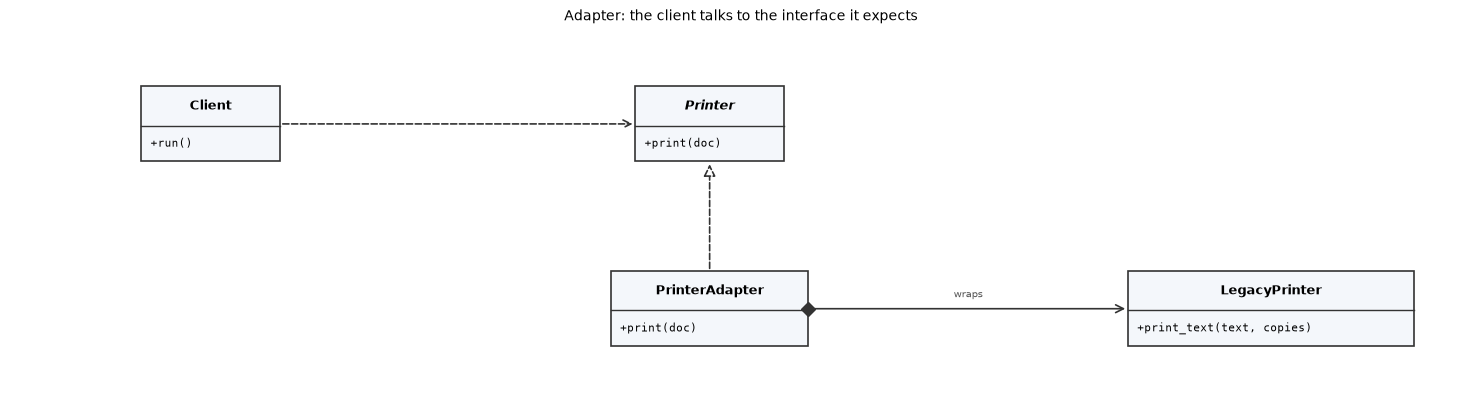

In [1]:
from dplab import class_diagram, tree_diagram, traced, trace

class_diagram(
    {"Printer": ["+print(doc)"], "PrinterAdapter": ["+print(doc)"], "LegacyPrinter": ["+print_text(text, copies)"], "Client": ["+run()"]},
    [("PrinterAdapter", "Printer", "implements"), ("PrinterAdapter", "LegacyPrinter", "has", "wraps"), ("Client", "Printer", "uses")],
    abstract={"Printer"}, layout={"Client": (-1.4, 0), "Printer": (0.2, 0), "PrinterAdapter": (0.2, 1), "LegacyPrinter": (2.0, 1)},
    title="Adapter: the client talks to the interface it expects")

2 x 'quarterly numbers'


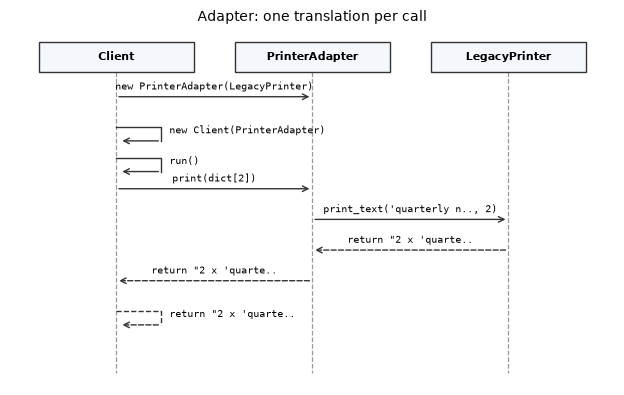

In [2]:
@traced
class LegacyPrinter:                                  # cannot change: third-party
    def print_text(self, text, copies):
        return f"{copies} x '{text}'"

@traced
class PrinterAdapter:                                 # what the client wants: print(doc)
    def __init__(self, legacy):
        self.legacy = legacy

    def print(self, doc):
        return self.legacy.print_text(doc["body"], doc.get("copies", 1))

@traced
class Client:
    def __init__(self, printer):
        self.printer = printer

    def run(self):
        return self.printer.print({"body": "quarterly numbers", "copies": 2})

with trace(returns=True) as t:
    print(Client(PrinterAdapter(LegacyPrinter())).run())
t.diagram(title="Adapter: one translation per call")

> **What to notice.** Python's duck typing means the `Printer` interface need not exist as a class at all: anything with a `print(doc)` method will do.
> The adapter is still worth naming, because it is the one place that knows about both sides.

## 2. Bridge

**Problem.** Shapes come in kinds (circle, square) and can be drawn by different renderers (vector, raster). Subclassing gives `VectorCircle`, `RasterCircle`, `VectorSquare`, ... : kinds times renderers classes.

**Structure.** Put the renderer *inside* the shape as a separate object. Shapes and renderers become two small hierarchies that vary independently: kinds plus renderers.

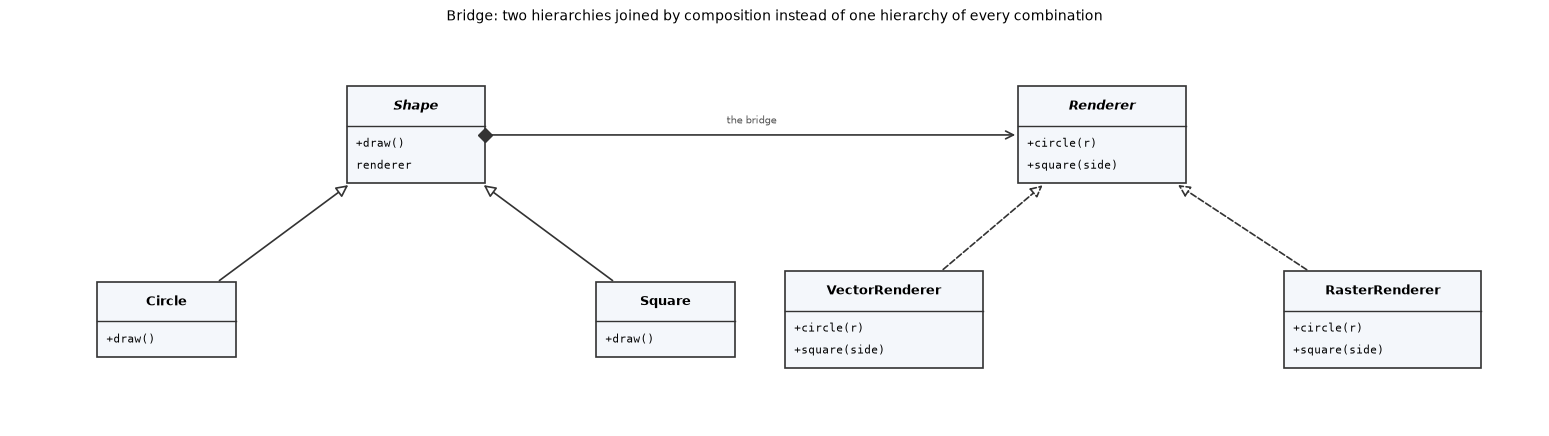

In [3]:
class_diagram(
    {"Shape": ["+draw()", "renderer"], "Circle": ["+draw()"], "Square": ["+draw()"],
     "Renderer": ["+circle(r)", "+square(side)"], "VectorRenderer": ["+circle(r)", "+square(side)"], "RasterRenderer": ["+circle(r)", "+square(side)"]},
    [("Circle", "Shape", "inherits"), ("Square", "Shape", "inherits"), ("VectorRenderer", "Renderer", "implements"),
     ("RasterRenderer", "Renderer", "implements"), ("Shape", "Renderer", "has", "the bridge")],
    abstract={"Shape", "Renderer"},
    layout={"Shape": (-1, 0), "Renderer": (1.2, 0), "Circle": (-1.8, 1), "Square": (-0.2, 1), "VectorRenderer": (0.5, 1), "RasterRenderer": (2.1, 1)},
    title="Bridge: two hierarchies joined by composition instead of one hierarchy of every combination")

In [4]:
class VectorRenderer:
    def circle(self, r):     return f"<circle r={r}/>"
    def square(self, side):  return f"<rect side={side}/>"

class RasterRenderer:
    def circle(self, r):     return f"{r * r * 3} pixels in a disc"
    def square(self, side):  return f"{side * side} pixels in a square"

class Shape:
    def __init__(self, renderer):
        self.renderer = renderer            # the bridge

class Circle(Shape):
    def __init__(self, renderer, r):
        super().__init__(renderer); self.r = r
    def draw(self):
        return self.renderer.circle(self.r)

class Square(Shape):
    def __init__(self, renderer, side):
        super().__init__(renderer); self.side = side
    def draw(self):
        return self.renderer.square(self.side)

for renderer in (VectorRenderer(), RasterRenderer()):
    for shape in (Circle(renderer, 2), Square(renderer, 3)):
        print(f"{type(shape).__name__:<7} with {type(renderer).__name__:<15} -> {shape.draw()}")

Circle  with VectorRenderer  -> <circle r=2/>
Square  with VectorRenderer  -> <rect side=3/>
Circle  with RasterRenderer  -> 12 pixels in a disc
Square  with RasterRenderer  -> 9 pixels in a square


## 3. Composite

**Problem.** Folders contain files and other folders. The client wants `size()` of anything without asking "is this a file or a folder?".

**Structure.** A common interface for leaves and containers; a container implements the operation by delegating to its children.

total size: 1005


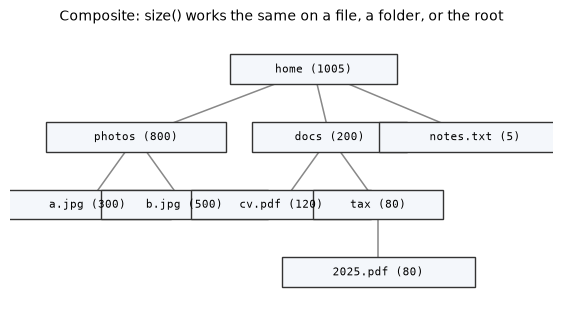

In [5]:
class File:
    def __init__(self, name, size):
        self.name, self._size = name, size
        self.children = []

    def size(self):
        return self._size

class Folder:
    def __init__(self, name, *children):
        self.name, self.children = name, list(children)

    def size(self):
        return sum(child.size() for child in self.children)     # leaves and folders answer the same question

    def add(self, child):
        self.children.append(child)
        return self

root = Folder("home",
              Folder("photos", File("a.jpg", 300), File("b.jpg", 500)),
              Folder("docs", File("cv.pdf", 120), Folder("tax", File("2025.pdf", 80))),
              File("notes.txt", 5))
print("total size:", root.size())
tree_diagram(root, lambda n: n.children, lambda n: f"{n.name} ({n.size()})", title="Composite: size() works the same on a file, a folder, or the root")

## 4. Decorator

**Problem.** Add responsibilities to individual objects at runtime, in any combination: bold *and* italic *and* uppercase, or just two of those. Subclassing every combination is hopeless.

**Structure.** A wrapper that has the same interface as the object it wraps, holds a reference to it, and adds something before or after delegating. Wrappers stack.

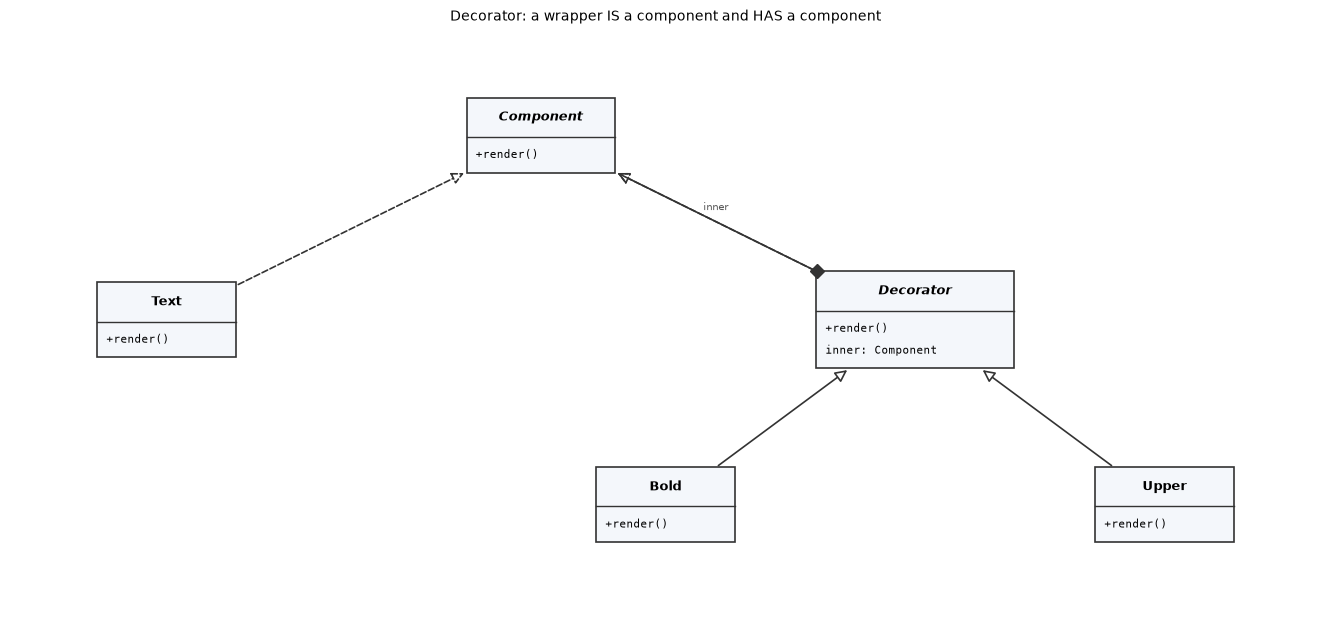

In [6]:
class_diagram(
    {"Component": ["+render()"], "Text": ["+render()"], "Decorator": ["+render()", "inner: Component"], "Bold": ["+render()"], "Upper": ["+render()"]},
    [("Text", "Component", "implements"), ("Decorator", "Component", "implements"), ("Decorator", "Component", "has", "inner"),
     ("Bold", "Decorator", "inherits"), ("Upper", "Decorator", "inherits")],
    abstract={"Component", "Decorator"},
    layout={"Component": (0, 0), "Text": (-1.2, 1), "Decorator": (1.2, 1), "Bold": (0.4, 2), "Upper": (2.0, 2)},
    title="Decorator: a wrapper IS a component and HAS a component")

**HELLO**
**HELLO**


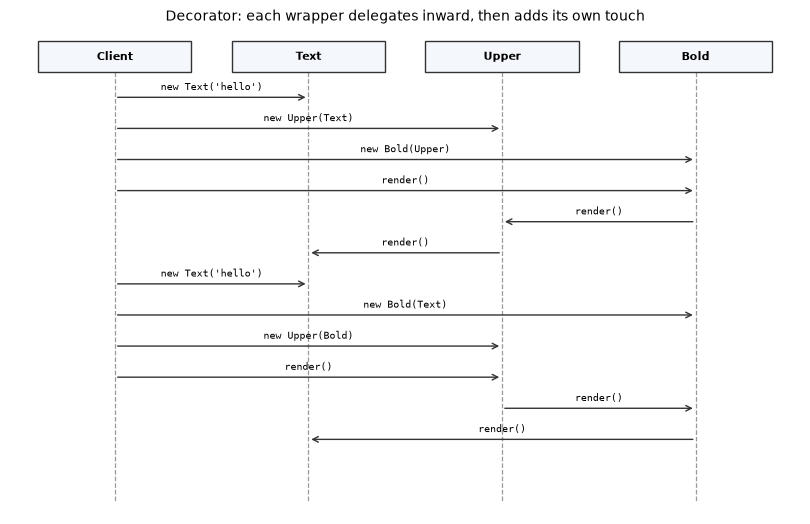

In [7]:
@traced
class Text:
    def __init__(self, s): self.s = s
    def render(self): return self.s

@traced
class Bold:
    def __init__(self, inner): self.inner = inner
    def render(self): return f"**{self.inner.render()}**"

@traced
class Upper:
    def __init__(self, inner): self.inner = inner
    def render(self): return self.inner.render().upper()

with trace() as t:
    print(Bold(Upper(Text("hello"))).render())
    print(Upper(Bold(Text("hello"))).render())
t.diagram(title="Decorator: each wrapper delegates inward, then adds its own touch")

In [8]:
# Python's @decorator syntax is the same idea applied to functions: wrap a callable in a callable with the same signature.
import functools, time

def timed(fn):
    @functools.wraps(fn)
    def wrapper(*args, **kwargs):
        t0 = time.perf_counter()
        result = fn(*args, **kwargs)
        print(f"{fn.__name__} took {(time.perf_counter() - t0) * 1000:.2f} ms")
        return result
    return wrapper

def logged(fn):
    @functools.wraps(fn)
    def wrapper(*args, **kwargs):
        print(f"calling {fn.__name__}{args}")
        return fn(*args, **kwargs)
    return wrapper

@logged
@timed                       # applied first (innermost), logged wraps the timed version
def slow_add(a, b):
    time.sleep(0.01)
    return a + b

print(slow_add(2, 3))

calling slow_add(2, 3)
slow_add took 10.82 ms
5


> **What to notice.** `Bold(Upper(x))` and `Upper(Bold(x))` give different strings: decorators compose, and order is part of the design.
> The function version stacks the same way, innermost first.

### Lab: Decorator Lab

Stack wrappers in different orders and watch the nesting picture and the result. Switch to the coffee domain, where every wrapper adds to a price.

Decorator Lab (static preview). Run this cell in JupyterLab for the interactive version.


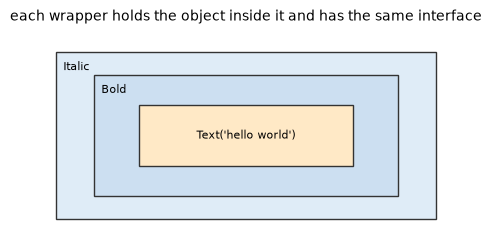

In [9]:
from dplab import decorator_lab

decorator_lab()

## Try it yourself

**Exercise 1.** Write an adapter that makes a `dict` look like an object with attribute access (`d.name` instead of `d["name"]`) using `__getattr__`. Which pattern is that closest to, Adapter or Proxy?

**Exercise 2.** Add a `Triangle` to the Bridge example and an `AsciiRenderer`. Count the classes you added versus the subclassing approach.

**Exercise 3.** Add `find(name)` to the Composite that returns the path to a file, e.g. `home/docs/tax/2025.pdf`.

**Exercise 4 (challenge).** Write a `retry(times)` function decorator that re-runs the function on exception, and stack it with `timed`. Does the order matter? Try both.

<details><summary>Solutions</summary>

```python
# Exercise 1: Adapter (it changes the interface). If it kept the dict interface and added caching or checks, it would be a Proxy.
class AttrDict:
    def __init__(self, d): self._d = d
    def __getattr__(self, name):
        try: return self._d[name]
        except KeyError: raise AttributeError(name)
print(AttrDict({"name": "ada"}).name)

# Exercise 2: 1 shape + 1 renderer = 2 classes. Subclassing: 3 shapes x 3 renderers = 9 classes, 5 of them new.

# Exercise 3
def find(node, name, path=""):
    here = f"{path}/{node.name}" if path else node.name
    if node.name == name: return here
    for child in node.children:
        found = find(child, name, here)
        if found: return found
    return None
print(find(root, "2025.pdf"))

# Exercise 4
def retry(times):
    def deco(fn):
        @functools.wraps(fn)
        def wrapper(*a, **k):
            for attempt in range(times):
                try: return fn(*a, **k)
                except Exception as e:
                    last = e
            raise last
        return wrapper
    return deco
# retry(timed(f)) times each attempt; timed(retry(f)) times the whole thing including retries. Order matters.
```

</details>

## Checkpoint quiz

Four quick questions. Answer them before reading the takeaways. If you miss one, the explanation points you to the section to re-read.

In [10]:
from dplab import quiz

quiz(2)

Checkpoint quiz, Module 2 (static preview). Run this cell in JupyterLab to answer interactively.

Q1. Adapter
    a) adds behaviour to an object at runtime
    b) makes an existing class fit the interface a client expects
    c) splits a hierarchy in two
    d) treats groups and single objects alike

Q2. Bridge separates
    a) interface from implementation so both can vary independently
    b) reads from writes
    c) creation from use
    d) the view from the model

Q3. Composite lets a client
    a) undo operations
    b) treat individual objects and groups of objects uniformly
    c) share objects to save memory
    d) observe changes

Q4. Decorator adds responsibilities
    a) by subclassing at compile time
    b) by wrapping an object with another object of the same interface
    c) by editing the class
    d) through a global registry


## Key takeaways

* Adapter changes an interface; the client and the adaptee stay untouched.
* Bridge replaces one hierarchy of combinations with two small ones joined by composition.
* Composite gives leaves and containers one interface so recursion falls out naturally.
* Decorator wraps an object with a same-interface object; wrappers stack and order matters. Python's `@` syntax is the function form.

**Next:** three more structural patterns about hiding, sharing and standing in. [GoF 3](03_Structural_Part_2.ipynb).

[Previous: GoF 1: Creational Patterns](01_Creational.ipynb)  |  [Course Index](../00_Start_Here.ipynb)  |  [Next: GoF 3: Structural Patterns, Part 2](03_Structural_Part_2.ipynb)